In [7]:
import math
import re
from dataclasses import dataclass


@dataclass
class Star:
    name: str
    ra: str
    dec: str


def parse_ra_hms_to_deg(ra_str: str) -> float:
    nums = re.findall(r"[-+]?\d+(?:\.\d+)?", ra_str)
    if len(nums) != 3:
        raise ValueError(f"Format AD invalide: {ra_str}")
    h, m, s = map(float, nums)
    return (h + m / 60.0 + s / 3600.0) * 15.0


def parse_dec_dms_to_deg(dec_str: str) -> float:
    sign = -1.0 if dec_str.strip().startswith("-") else 1.0
    nums = re.findall(r"[-+]?\d+(?:\.\d+)?", dec_str)
    if len(nums) != 3:
        raise ValueError(f"Format DEC invalide: {dec_str}")
    d, m, s = map(float, nums)
    d = abs(d)
    return sign * (d + m / 60.0 + s / 3600.0)


def shortest_delta_ra_deg(ra_deg: float, ra_ref_deg: float) -> float:
    """
    Différence d'AD minimale dans [-180 ; +180]
    pour éviter les problèmes au passage 0h / 24h.
    """
    delta = ra_deg - ra_ref_deg
    delta = (delta + 180.0) % 360.0 - 180.0
    return delta


def project_relative_radec_simple(stars, origin_index=0):
    """
    Transformation simple demandée :
    - une étoile de référence devient (0,0)
    - x = delta_RA * cos(dec_ref)
    - y = delta_DEC
    """
    coords = []
    for s in stars:
        ra_deg = parse_ra_hms_to_deg(s.ra)
        dec_deg = parse_dec_dms_to_deg(s.dec)
        coords.append((ra_deg, dec_deg))

    ra_ref, dec_ref = coords[origin_index]
    cos_ref = math.cos(math.radians(dec_ref))

    points = []
    for ra_deg, dec_deg in coords:
        delta_ra = shortest_delta_ra_deg(ra_deg, ra_ref)
        delta_dec = dec_deg - dec_ref

        x = delta_ra * cos_ref
        y = delta_dec
        points.append((x, y))

    return points

def rotate_point(x, y, theta_deg):
    theta = math.radians(theta_deg)
    xr = x * math.cos(theta) - y * math.sin(theta)
    yr = x * math.sin(theta) + y * math.cos(theta)
    return xr, yr

def normalize_points(points, theta_deg=0, flip_y=False):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    for i in range(len(xs)):
        xs[i], ys[i] = rotate_point(xs[i], ys[i], theta_deg)

    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    dx = max_x - min_x
    dy = max_y - min_y

    sc = max(dx, dy)

    normalized = []
    for i in range(len(xs)):
        xn = (xs[i] - min_x) / sc
        yn = (ys[i] - min_y) / sc
        if flip_y:
            yn = 1.0 - yn
        normalized.append((xn, yn))

    return normalized


def to_kotlin_star_pattern(points, stars):
    lines = ["starPattern = listOf("]
    for (x, y), star in zip(points, stars):
        lines.append(f"    FractionalPoint({x:.3f}f, {y:.3f}f), // {star.name}")
    lines.append(")")
    return "\n".join(lines)


# -------------------------------------------------------------------
# Exemple : Grande Casserole
# -------------------------------------------------------------------

stars = [
    Star("Alkaid", "13h 47m 32.43776s", "+49° 18' 47.7602\""),
    Star("Mizar",  "13h 23m 55.54048s", "+54° 55' 31.2671\""),
    Star("Alioth", "12h 54m 01.74959s", "+55° 57' 35.3627\""),
    Star("Megrez", "12h 15m 25.56063s", "+57° 01' 57.4156\""),
    Star("Dubhe",  "11h 03m 43.67152s", "+61° 45' 03.7249\""),
    Star("Merak",  "11h 01m 50.47654s", "+56° 22' 56.7339\""),
    Star("Phecda", "11h 53m 49.84732s", "+53° 41' 41.1350\""),
]

# Choix arbitraire de l'origine : ici Alkaid
origin_index = 1

raw_points = project_relative_radec_simple(stars, origin_index=origin_index)
fractional_points = normalize_points(raw_points, 36)

print(f"Origine choisie : {stars[origin_index].name}")
print()
print(to_kotlin_star_pattern(fractional_points, stars))
print()
print("lineConnections = listOf(")
print("    0 to 1,")
print("    1 to 2,")
print("    2 to 3,")
print("    3 to 4,")
print("    4 to 5,")
print("    5 to 6,")
print("    6 to 3,")
print(")")

Origine choisie : Mizar

starPattern = listOf(
    FractionalPoint(1.000f, 0.314f), // Alkaid
    FractionalPoint(0.771f, 0.411f), // Mizar
    FractionalPoint(0.616f, 0.347f), // Alioth
    FractionalPoint(0.422f, 0.256f), // Megrez
    FractionalPoint(0.000f, 0.171f), // Dubhe
    FractionalPoint(0.111f, 0.000f), // Merak
    FractionalPoint(0.401f, 0.084f), // Phecda
)

lineConnections = listOf(
    0 to 1,
    1 to 2,
    2 to 3,
    3 to 4,
    4 to 5,
    5 to 6,
    6 to 3,
)


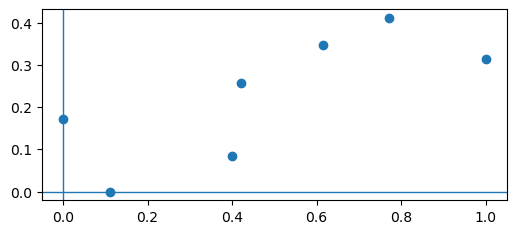

In [ ]:
import matplotlib.pyplot as plt

def plot_points(points):
    """
    points : liste de tuples (x, y)
    """
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    plt.figure(figsize=(6, 6))
    plt.scatter(xs, ys)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()


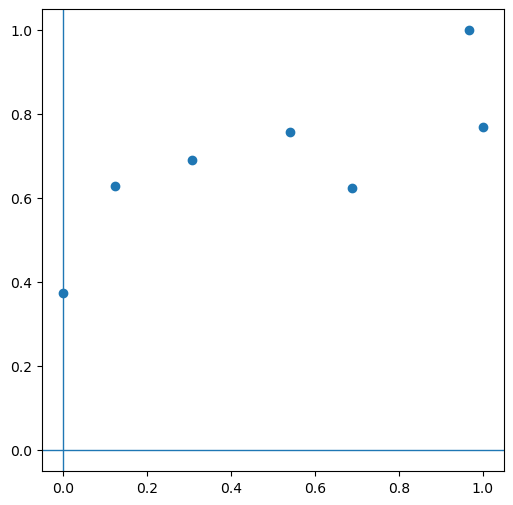

In [15]:
raw_points = project_relative_radec_simple(stars, origin_index=origin_index)
fractional_points = normalize_points(raw_points, 175, True)
plot_points(fractional_points)

In [16]:
print(f"Origine choisie : {stars[origin_index].name}")
print()
print(to_kotlin_star_pattern(fractional_points, stars))
print()
print("lineConnections = listOf(")
print("    0 to 1,")
print("    1 to 2,")
print("    2 to 3,")
print("    3 to 4,")
print("    4 to 5,")
print("    5 to 6,")
print("    6 to 3,")
print(")")

Origine choisie : Mizar

starPattern = listOf(
    FractionalPoint(0.000f, 0.375f), // Alkaid
    FractionalPoint(0.125f, 0.630f), // Mizar
    FractionalPoint(0.306f, 0.690f), // Alioth
    FractionalPoint(0.542f, 0.758f), // Megrez
    FractionalPoint(0.968f, 1.000f), // Dubhe
    FractionalPoint(1.000f, 0.769f), // Merak
    FractionalPoint(0.688f, 0.625f), // Phecda
)

lineConnections = listOf(
    0 to 1,
    1 to 2,
    2 to 3,
    3 to 4,
    4 to 5,
    5 to 6,
    6 to 3,
)
